In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from collections import defaultdict 
import ast

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '..'))
from symlie.misc.viz import plot2d

from symlie.misc.utils_results import pivot, assert_columns_same, get_and_check_Ps, stringify_dict, aggregate_dataset, plot_best, return_table, plot_pivot
from symlie.misc.utils import print_nested_keys
from symlie.misc.wandb import update_results_df, get_inspect_df, get_inspectdev_df
from symlie.model.setup import load_P_pred

sys.path.append(os.path.join(os.getcwd(), '../sympdee/sympde/viz'))
from sympdee.sympde.viz.general_plots import savefig 

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RELOAD_DF = False

store_dir = '../store'
df_path = os.path.join(store_dir, 'combi_show_dev.csv')

if RELOAD_DF:
    df = get_inspectdev_df(tags = ['combi_show_dev'])
    df.to_csv(df_path, index=False)
df = pd.read_csv(df_path)

# df = df[df['n_train'] > 10]
# df = df[df['net'] != 'EMLP']

import pickle 
with open('d_pivots.pkl', 'rb') as f:
    result_dicts = pickle.load(f)

df


,lr,net,bias,name,seed,tags,test,A_low,n_val,train,...,vanilla_layer_dims,implicit_layer_dims,lossweight_do_tilde,do_return_datamodule,hidden_implicit_layers,lossweight_do_tilde_mmd,run_name,test_loss_o0,test_loss_o1,test_loss_y
0,0.010,CombiTrain,False,NaN,3,"['combi_show_dev', 'vanilla']",True,NaN,1000,True,...,"[10, 10, 1]","[0, 0]",0,False,NaN,0,zany-snowflake-4153,NaN,NaN,16.172945
1,0.100,CombiTrain,False,NaN,3,"['combi_show_dev', 'vanilla']",True,NaN,1000,True,...,"[10, 10, 1]","[0, 0]",0,False,NaN,0,dashing-voice-4154,NaN,NaN,16.726116
2,0.001,CombiTrain,False,NaN,2,"['combi_show_dev', 'vanilla']",True,NaN,1000,True,...,"[10, 10, 1]","[0, 0]",0,False,NaN,0,eternal-vortex-4152,NaN,NaN,16.883253
3,0.001,CombiTrain,False,NaN,3,"['combi_show_dev', 'vanilla']",True,NaN,1000,True,...,"[10, 10, 1]","[0, 0]",0,False,NaN,0,eager-vortex-4151,NaN,NaN,16.863384
4,0.010,CombiTrain,False,NaN,2,"['combi_show_dev', 'vanilla']",True,NaN,1000,True,...,"[10, 10, 1]","[0, 0]",0,False,NaN,0,leafy-surf-4150,NaN,NaN,17.319950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,0.001,CombiTrain,True,NaN,1,"['combi_show_dev', 'train']",True,NaN,1000,True,...,"[7, 7, 1]","[[56, 56], [8, 8]]",0,False,NaN,0,flowing-snow-3535,0.000854,0.001461,0.129313
568,0.100,CombiTrain,True,NaN,1,"['combi_show_dev', 'train']",True,NaN,1000,True,...,"[7, 7, 1]","[[56, 56], [8, 8]]",0,False,NaN,0,playful-sky-3537,0.000223,0.005831,0.256803
569,0.010,CombiTrain,True,NaN,1,"['combi_show_dev', 'train']",True,NaN,1000,True,...,"[7, 7, 1]","[[56, 56], [8, 8]]",0,False,NaN,0,balmy-cloud-3535,0.005209,0.005085,0.082867
570,0.100,CombiTrain,True,NaN,1,"['combi_show_dev', 'train']",True,NaN,1000,True,...,"[7, 7, 1]","[[56, 56], [8, 8]]",0,False,NaN,0,stellar-dust-3531,0.007504,0.000742,0.134200


In [3]:
datasets = {
    'Sine 1D' : '../data/sine1d',
    r'$O(5)$ (Finzi 2021)' : '../data/o5synth',
}

method_dict = {
    'train' : 'ELL',
    'analytic' : 'Analytic',
    'vanilla' : 'Vanilla',
    'emlp' : 'EMLP (Finzi 2021)',
}

title_dict = {
    'bias' : 'With bias',
    'no_bias' : 'Without bias'

}

colors = {'Analytic ELL': 'C0', 'ELL': 'C1', 'Vanilla': 'C2', 'EMLP (Finzi 2021)': 'C3'}

method_dict = defaultdict(lambda: None, method_dict)

    

In [4]:
title_dict = {
        'dataset' :{
            'sine1d' : 'Sine 1D',
            'sine2d' : 'Sine 2D',
            'flower' : 'Flower',
            'mnist' : 'MNIST',
        },
        'eps_mult' : {
            '[0, 0, 1, 0]' : r'$Z(7)$',
            '[0, 0, 1, 1]' : r'$SO(2)$',
            '[0, 1, 1, 1]' : r'$SE(2)$',
        },
    }

plot_ddd_ids = [
    ('sine1d', '[0, 0, 1, 0]', '0.5'),
    ('sine2d', '[0, 0, 1, 1]', '0.1'),
    ('sine2d', '[0, 1, 1, 1]', '0.1'),
    ('flower', '[0, 0, 1, 1]', '0.1'),
    ('flower', '[0, 1, 1, 1]', '0.1'),
]

In [5]:
d_datas2 = {}

for index, result_dict in result_dicts.items():

    dataset, (eps_mult, noise_std) = index

    if (dataset, eps_mult, noise_std) not in plot_ddd_ids:
        continue


    d_data = result_dict['d_pivot'].unstack().reset_index(level=0, drop=True).reset_index().rename(columns = {0 :  'test_loss_y', 'net': 'method'}).replace({'method' : {'Trained' : 'ELL', 'Pre-calculated' : 'Analytic ELL'}})
    title = title_dict['dataset'][dataset] + ', ' + title_dict['eps_mult'][eps_mult]

    d_data['bias'] = False

    d_datas2[title] = {}

    # bias_keys = {False : 'no_bias'}
    # for bias_val, bias_key in bias_keys.items():
    bias_key = 'no_bias'
    bias_val = False
        
    d_bias = d_data[d_data['bias'] == bias_val]
    d_datas2[title][bias_key] = {'d_raw' : d_bias}

    d_datas2[title][bias_key]['lr'] = {}
    d_lrs = d_bias.groupby('lr')
    for lr, d_lr in d_lrs:
        d_datas2[title][bias_key]['lr'][lr] = d_lr

    print(d_data.shape)

# print_nested_keys(d_datas2)



(81, 6)
(54, 6)
(54, 6)
(54, 6)
(54, 6)


In [6]:
# d_datas = {}

# for dataset, data_dir in datasets.items():
#     d_data = df[df['data_dir'] == data_dir]
#     d_data = d_data.reset_index(drop=True)

#     d_data['method'] = d_data['tags'].apply(lambda x: ''.join([method_dict[x_i] for x_i in ast.literal_eval(x) if method_dict[x_i] is not None]))

#     columns = ['test_loss_y', 'max_epochs', 'method', 'n_train', 'seed', 'lr', 'bias']
#     cols_groupby = ['method', 'n_train']
#     loss = 'test_loss_y'
#     d_data = d_data[columns]

#     d_datas[dataset] = {}


#     bias_keys = {True : 'bias', False : 'no_bias'}
#     for bias_val, bias_key in bias_keys.items():
#         d_bias = d_data[d_data['bias'] == bias_val]
#         d_datas[dataset][bias_key] = {'d_raw' : d_bias}

#         d_datas[dataset][bias_key]['lr'] = {}
#         d_lrs = d_bias.groupby('lr')
#         for lr, d_lr in d_lrs:
#             d_datas[dataset][bias_key]['lr'][lr] = d_lr
        
        
# print_nested_keys(d_datas)


In [7]:
def get_df_best(d):
    stats_df = d.groupby(['method', 'n_train', 'lr']).agg({'test_loss_y': ['mean', 'std']}).reset_index()
    stats_df.columns = ['method', 'n_train', 'lr', 'mean_loss', 'std_dev']

    idx = stats_df.groupby(['method', 'n_train'])['mean_loss'].idxmin()
    get_df_best = stats_df.loc[idx].reset_index(drop=True)
    return get_df_best

# for dataset, ds in d_datas.items():
#     for bias_key, d in ds.items():
#         d['d_best'] = get_df_best(d['d_raw'])

for dataset, ds in d_datas2.items():
    for bias_key, d in ds.items():
        d['d_best'] = get_df_best(d['d_raw'])

print_nested_keys(d_datas2)

Sine 1D, $Z(7)$
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
Sine 2D, $SO(2)$
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
Sine 2D, $SE(2)$
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
Flower, $SO(2)$
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
Flower, $SE(2)$
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best


In [8]:
# for ylog in [False]:
#     n_cols= len(d_datas) + 1
#     n_rows = len(d_datas['Sine 1D'])

#     fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), tight_layout = True, sharey = False)

#     handles, labels = [], []

#     for i, (dataset, ds) in enumerate(d_datas.items()):
#         for j, (bias_key, d) in enumerate(ds.items()):
#             ax = axs[j, i]
#             d_best = d['d_best']
            
#             for method, group in d_best.groupby('method'):
#                 ax.errorbar(group['n_train'], group['mean_loss'], yerr=group['std_dev'], fmt='-o', label=method, color=colors[method], capsize = 2)

#             ax.set_xscale('log')
#             if ylog:
#                 ax.set_yscale('log')

#             if j == 0:
#                 ax.set_title(dataset)
#             if i == 0:
#                 ax.set_ylabel(title_dict[bias_key])


#             handles_ax, labels_ax = ax.get_legend_handles_labels()
#             for handle, label in zip(handles_ax, labels_ax):
#                 if label not in labels:
#                     handles.append(handle)
#                     labels.append(label)

#     ax = axs[0, 2]
#     ax.set_title('Hopefully some PDE dataset')

#     fig.supxlabel('Train size')
#     fig.supylabel('Test loss')
#     fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.15), ncol = len(handles))

# savefig(fig, 'implicit_results_best', '5-experiments', bbox_inches = 'tight')

In [9]:
d_datas2['Flower, $SE(2)$']['no_bias']['d_best']

,method,n_train,lr,mean_loss,std_dev
0,ELL,100,0.001,1.171049,NaN
1,ELL,1000,0.100,0.558807,NaN
2,ELL,10000,0.010,0.077548,NaN
3,Vanilla,100,0.010,2.351155,0.176815
4,Vanilla,1000,0.010,0.468418,0.044155
5,Vanilla,10000,0.001,0.098035,0.002814


In [10]:
ds

{'no_bias': {'d_raw':     n_train     lr   method  seed  test_loss_y   bias
  0       100  0.001  Vanilla     1     2.616742  False
  1       100  0.001  Vanilla     2     2.260929  False
  2       100  0.001  Vanilla     3     2.572932  False
  3       100  0.001      ELL     1          NaN  False
  4       100  0.001      ELL     2     1.171049  False
  5       100  0.001      ELL     3          NaN  False
  6       100  0.010  Vanilla     1     2.467564  False
  7       100  0.010  Vanilla     2     2.147691  False
  8       100  0.010  Vanilla     3     2.438209  False
  9       100  0.010      ELL     1          NaN  False
  10      100  0.010      ELL     2     2.084975  False
  11      100  0.010      ELL     3          NaN  False
  12      100  0.100  Vanilla     1          NaN  False
  13      100  0.100  Vanilla     2          NaN  False
  14      100  0.100  Vanilla     3     3.812638  False
  15      100  0.100      ELL     1          NaN  False
  16      100  0.100      EL

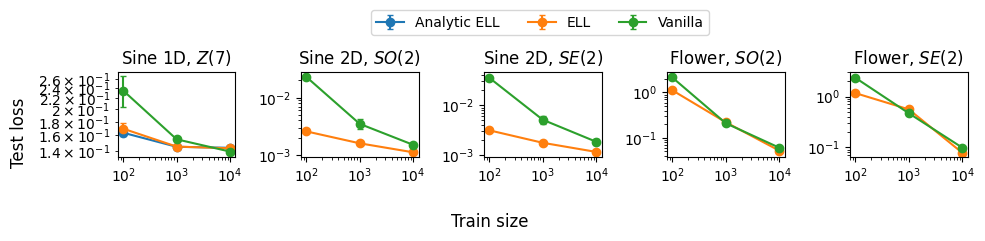

In [14]:
for ylog in [True]:
    n_cols= len(d_datas2) 
    n_rows = len(d_datas2['Sine 1D, $Z(7)$'])

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows), tight_layout = True, sharey = False)

    handles, labels = [], []

    for i, (dataset, ds) in enumerate(d_datas2.items()):
        ax = axs[i]
        d_best = ds['no_bias']['d_best']

        for method, group in d_best.groupby('method'):
            ax.errorbar(group['n_train'], group['mean_loss'], yerr=group['std_dev'], fmt='-o', label=method, color=colors[method], capsize = 2)

        ax.set_xscale('log')
        if ylog:
            ax.set_yscale('log')

        ax.set_title(dataset)


        handles_ax, labels_ax = ax.get_legend_handles_labels()
        for handle, label in zip(handles_ax, labels_ax):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.supxlabel('Train size')
    fig.supylabel('Test loss')
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.15), ncol = len(handles))

savefig(fig, 'best_weightmapping', '5-experiments', bbox_inches = 'tight')

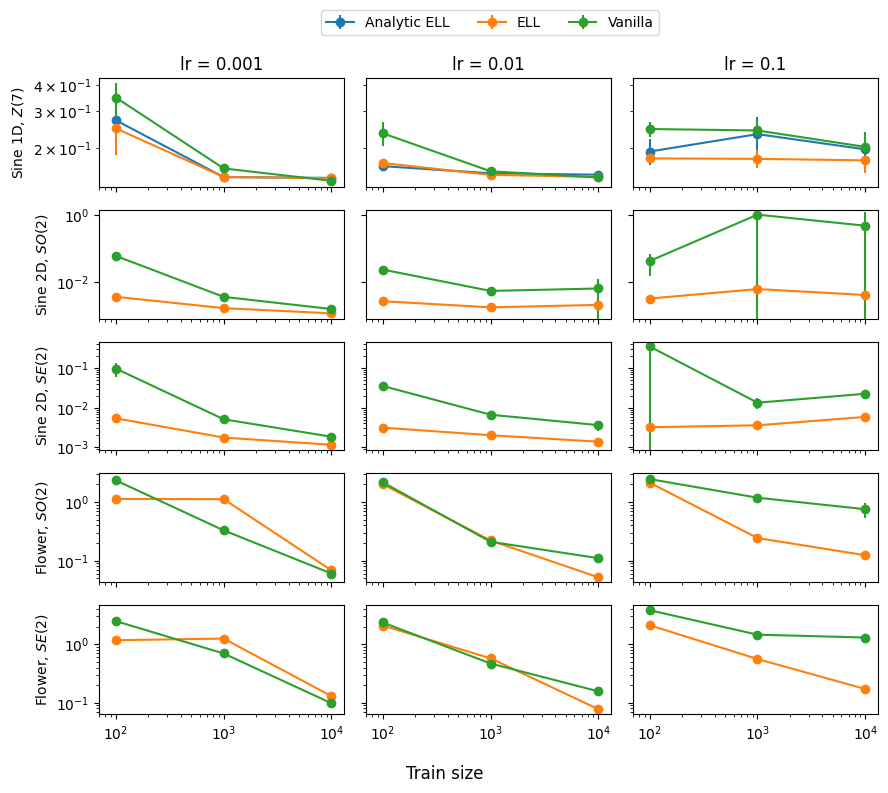

In [13]:
for ylog in [True]:
    n_cols = len(d_datas2['Sine 1D, $Z(7)$']['no_bias']['lr'])
    n_rows = len(d_datas2['Sine 1D, $Z(7)$']) * len(d_datas2)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 1.5*n_rows), tight_layout = True, sharex = True, sharey = 'row')

    handles, labels = [], []

    row = 0
    for i, (dataset, ds) in enumerate(d_datas2.items()):
            bias_key = 'no_bias'
            d = ds[bias_key]
        # for j, (bias_key, d) in enumerate(ds.items()):
            for k, (lr, d_lr) in enumerate(d['lr'].items()):
                ax = axs[row, k]

                grouped = d_lr.groupby(['method', 'n_train'])
                means = grouped['test_loss_y'].mean().reset_index()
                std_devs = grouped['test_loss_y'].std().reset_index()

                # Get the corresponding standard deviations for the group
                for method, group in means.groupby('method'):
                    current_std_dev = std_devs[std_devs['method'] == method]['test_loss_y'].values
                    ax.errorbar(group['n_train'], group['test_loss_y'], yerr=current_std_dev, fmt='-o', label=method, color=colors[method], capsize=0)

                ax.set_xscale('log')
                if ylog: ax.set_yscale('log')

                if row == 0:
                    ax.set_title(f'lr = {lr}')

                if k == 0:
                    ax.set_ylabel(f'{dataset}')

                handles_ax, labels_ax = ax.get_legend_handles_labels()
                for handle, label in zip(handles_ax, labels_ax):
                    if label not in labels:
                        handles.append(handle)
                        labels.append(label)

                ax.set_xlim(10**2*0.7, 10**4*1.3)

            row += 1


    # ax = axs[0, 2]
    # ax.set_ylim(0, 0.6)

    fig.supxlabel('Train size')
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.05), ncol = len(handles))
    fig.tight_layout()
    plt.show()

    savefig(fig, 'best_weightmapping_all' + ('_log' if ylog else ''), '5-experiments', bbox_inches = 'tight')
